# **Intro: Problem Definition**
**Problem**

This notebook implements Face Verification (1:1) — a “Digital Doorman”.
Given two images (ID photo and selfie), the goal is to predict whether they belong to the same person (label=1) or different people (label=0).

**Dataset**

I use the LFW deep-funneled face dataset with a pairs.csv file. Each row forms a pair of images:

 - Same person pairs: two images of the same identity

 - Different people pairs: images from two different identities

The dataset is balanced based on my parsing results: 3000 same vs 3000 different.

**Why thresholds matter**

Face verification is not only about accuracy. In real systems we choose a threshold:

 - Strict threshold (security) → fewer false accepts (FP), but more false rejects (FN)

 - Loose threshold (convenience) → fewer false rejects (FN), but more false accepts (FP)

In [2]:
!pip install face_recognition

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=94bc2e817013de392c5897605fcb9677e8585af88aa885fe4b5db9c3426c2f76
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


In [41]:
# !pip install face_recognition
import os, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2
import face_recognition
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, classification_report, mean_squared_error, r2_score

In [4]:
!unzip "/content/archive (3).zip" -d dataset_ml

Streaming output truncated to the last 5000 lines.
  inflating: dataset_ml/lfw-deepfunneled/lfw-deepfunneled/Luiz_Inacio_Lula_da_Silva/Luiz_Inacio_Lula_da_Silva_0022.jpg  
  inflating: dataset_ml/lfw-deepfunneled/lfw-deepfunneled/Luiz_Inacio_Lula_da_Silva/Luiz_Inacio_Lula_da_Silva_0023.jpg  
  inflating: dataset_ml/lfw-deepfunneled/lfw-deepfunneled/Luiz_Inacio_Lula_da_Silva/Luiz_Inacio_Lula_da_Silva_0024.jpg  
  inflating: dataset_ml/lfw-deepfunneled/lfw-deepfunneled/Luiz_Inacio_Lula_da_Silva/Luiz_Inacio_Lula_da_Silva_0025.jpg  
  inflating: dataset_ml/lfw-deepfunneled/lfw-deepfunneled/Luiz_Inacio_Lula_da_Silva/Luiz_Inacio_Lula_da_Silva_0026.jpg  
  inflating: dataset_ml/lfw-deepfunneled/lfw-deepfunneled/Luiz_Inacio_Lula_da_Silva/Luiz_Inacio_Lula_da_Silva_0027.jpg  
  inflating: dataset_ml/lfw-deepfunneled/lfw-deepfunneled/Luiz_Inacio_Lula_da_Silva/Luiz_Inacio_Lula_da_Silva_0028.jpg  
  inflating: dataset_ml/lfw-deepfunneled/lfw-deepfunneled/Luiz_Inacio_Lula_da_Silva/Luiz_Inacio_Lula_d

In [5]:
# Define paths to extracted LFW folders and the pairs file
LFW_DIR   = "/content/dataset_ml/lfw-deepfunneled/lfw-deepfunneled"
PAIRS_CSV = "/content/dataset_ml/pairs.csv"

# Sanity check that paths exist before continuingч
print("LFW_DIR exists:", os.path.exists(LFW_DIR))
print("PAIRS_CSV exists:", os.path.exists(PAIRS_CSV))

LFW_DIR exists: True
PAIRS_CSV exists: True


In [6]:
pairs_raw = pd.read_csv(PAIRS_CSV)
print(pairs_raw.columns)
pairs_raw.head()

Index(['name', 'imagenum1', 'imagenum2', 'Unnamed: 3'], dtype='object')


,name,imagenum1,imagenum2,Unnamed: 3
0,Abel_Pacheco,1,4,NaN
1,Akhmed_Zakayev,1,3,NaN
2,Akhmed_Zakayev,2,3,NaN
3,Amber_Tamblyn,1,2,NaN
4,Anders_Fogh_Rasmussen,1,3,NaN


In [7]:
def parse_pairs_correct(pairs_raw: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for _, r in pairs_raw.iterrows():

        # SAME PERSON
        if pd.isna(r["Unnamed: 3"]):
            rows.append({
                "name1": r["name"],
                "img1": int(r["imagenum1"]),
                "name2": r["name"],
                "img2": int(r["imagenum2"]),
                "label": 1
            })

        # DIFFERENT PERSON
        else:
            rows.append({
                "name1": r["name"],
                "img1": int(r["imagenum1"]),
                "name2": r["imagenum2"],      # this is NAME
                "img2": int(r["Unnamed: 3"]), # this is IMAGE NUMBER
                "label": 0
            })

    return pd.DataFrame(rows)

In [8]:
pairs = parse_pairs_correct(pairs_raw)
pairs.head()

,name1,img1,name2,img2,label
0,Abel_Pacheco,1,Abel_Pacheco,4,1
1,Akhmed_Zakayev,1,Akhmed_Zakayev,3,1
2,Akhmed_Zakayev,2,Akhmed_Zakayev,3,1
3,Amber_Tamblyn,1,Amber_Tamblyn,2,1
4,Anders_Fogh_Rasmussen,1,Anders_Fogh_Rasmussen,3,1


In [9]:
pairs["label"].value_counts()

,count
label,
1,3000
0,3000


# **Phase A: Data & EDA (Days 1-3)**



# **EDA: What I see in the data**
**1) Class balance**

The class distribution plot shows equal counts for both labels:

 - `label=1 (Same)` = 3000

 - `label=0 (Different`) = 3000

This is good because model metrics are not distorted by class `imbalance`.

**2) Pixel-distance feature distributions**

I created baseline features from resized grayscale faces (64×64):

 - `euclid_dist`: Euclidean distance between flattened images

 - `l1_dist`: L1 distance between flattened images

The histogram of euclid_dist shows strong overlap between the “Same” and “Different” distributions.
This means simple pixel distances are not robust enough to separate identities (lighting, pose, expression still change distances a lot).

**3) Correlation between engineered features**

The correlation heatmap shows:

 - `corr(euclid_dist, l1_dist) ≈ 0.98` → these two features are almost redundant

 - correlation with label is weak (small negative values)

EDA conclusion: the baseline feature space is weak and highly correlated, so we need stronger identity representations (embeddings).

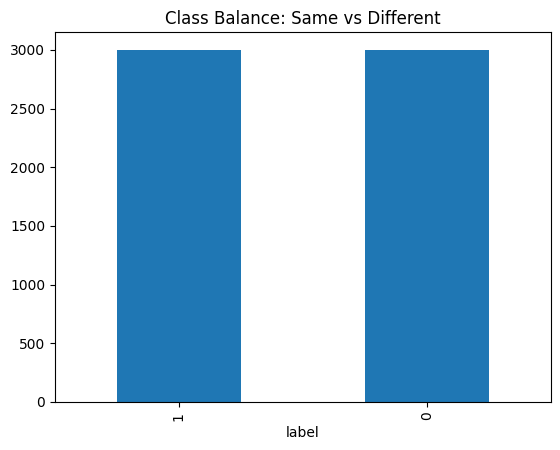

In [10]:
pairs["label"].value_counts().plot(kind="bar")
plt.title("Class Balance: Same vs Different")
plt.show()

In [11]:
def load_face_gray(name, img_num, size=(64, 64)):
    path = f"{LFW_DIR}/{name}/{name}_{img_num:04d}.jpg"
    if not os.path.exists(path):
        return None
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, size)
    return img.astype(np.float32) / 255.0

In [12]:
rows = []

for _, r in pairs.iterrows():
    img1 = load_face_gray(r["name1"], r["img1"])
    img2 = load_face_gray(r["name2"], r["img2"])

    if img1 is None or img2 is None:
        continue

    diff = img1.flatten() - img2.flatten()

    rows.append({
        "euclid_dist": np.linalg.norm(diff),
        "l1_dist": np.sum(np.abs(diff)),
        "label": r["label"]
    })

In [13]:
df = pd.DataFrame(rows)
df.head()

,euclid_dist,l1_dist,label
0,22.518572,988.078491,1
1,21.024551,1033.741211,1
2,16.922714,815.760803,1
3,9.285790,391.423523,1
4,32.006668,1748.258789,1


In [14]:
df.columns

Index(['euclid_dist', 'l1_dist', 'label'], dtype='object')

In [15]:
df["label"].value_counts()

,count
label,
1,3000
0,3000


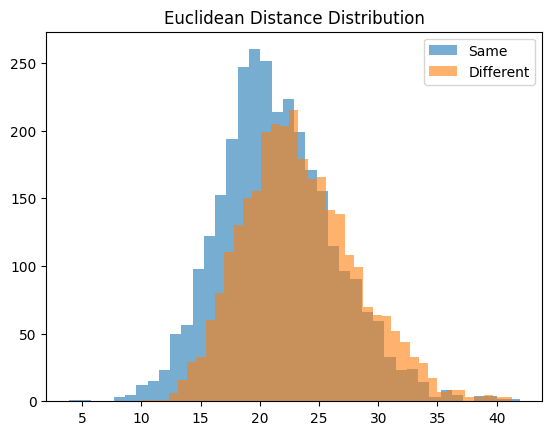

In [16]:
plt.hist(df[df["label"]==1]["euclid_dist"], bins=40, alpha=0.6, label="Same")
plt.hist(df[df["label"]==0]["euclid_dist"], bins=40, alpha=0.6, label="Different")
plt.legend()
plt.title("Euclidean Distance Distribution")
plt.show()

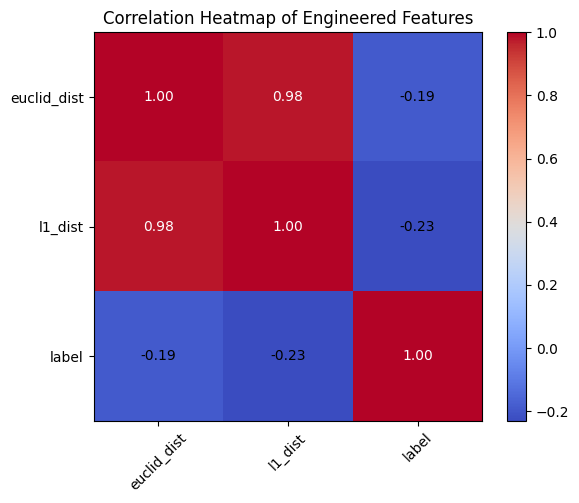

In [17]:
corr = df.corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap="coolwarm")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center", va="center",
            color="white" if abs(corr.iloc[i, j]) > 0.5 else "black"
        )

plt.title("Correlation Heatmap of Engineered Features")
plt.tight_layout()
plt.show()

# **Phase B: Modeling & Tuning (Days 4-10)**

# **Method: Why these models?**
**Baseline method: pixel distances + classical ML**

To establish a simple baseline, I computed distances directly from pixel values:

 - input: `(euclid_dist, l1_dist)`

 - target: `label` (same vs different)

Models:

 - **Logistic Regression (LR)**: simple, fast, interpretable; works well when the separation is mostly linear/monotonic.

 - **Random Forest (RF)**: non-linear model that can capture complex decision rules (but with only 2 highly correlated features, gains may be limited).

**Improved method: CNN face embeddings + similarity features**

Pixel distances are weak, so I switched to face embeddings:

 - I use face_recognition.face_encodings() to extract a 128-D embedding per image.

 - Then I engineer two similarity features:

   - Euclidean distance between embeddings

   - Cosine similarity between embeddings

This matches how real verification systems work: “same person” pairs should have small embedding distance and high cosine similarity.

In [18]:
X = df[["euclid_dist", "l1_dist"]]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

log_reg.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', LogisticRegression(max_iter=2000))])

In [20]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [21]:
# Probabilities
proba_lr = log_reg.predict_proba(X_test)[:, 1]
proba_rf = rf.predict_proba(X_test)[:, 1]

# ROC data
fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, proba_rf)

auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)

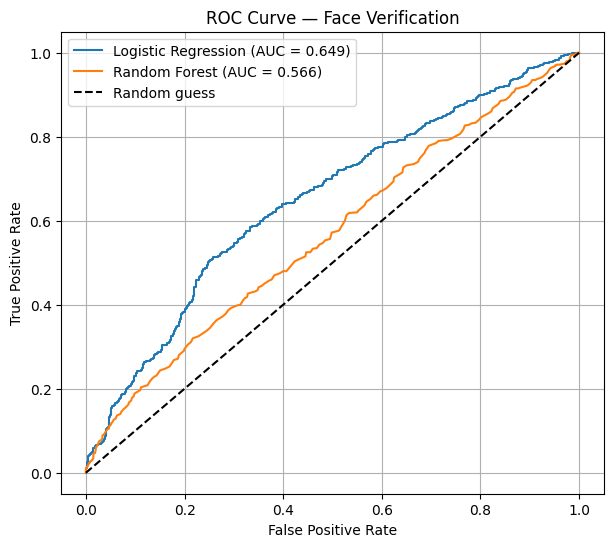

In [22]:
# Plot
plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Face Verification")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
optimal_idx = np.argmax(tpr_rf - fpr_rf)
optimal_threshold = _[optimal_idx]

print("Optimal threshold (balanced security):", optimal_threshold)

Optimal threshold (balanced security): 0.685


In [24]:
strict_threshold = 0.8   # High security (low false positives)
loose_threshold = 0.3    # Convenience (low false negatives)

print("Strict threshold:", strict_threshold)
print("Loose threshold:", loose_threshold)

Strict threshold: 0.8
Loose threshold: 0.3


In [27]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print("Best Random Forest params:", grid.best_params_)

Best Random Forest params: {'max_depth': 10, 'n_estimators': 200}


In [28]:
pred_lr = log_reg.predict(X_test)
pred_rf = best_rf.predict(X_test)

In [29]:
print("Logistic Regression F1:", f1_score(y_test, pred_lr))
print("Random Forest F1:", f1_score(y_test, pred_rf))

Logistic Regression F1: 0.62
Random Forest F1: 0.5454545454545454


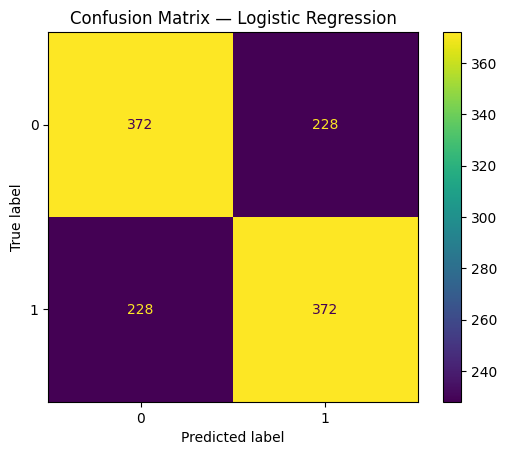

In [30]:
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_lr)).plot()
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

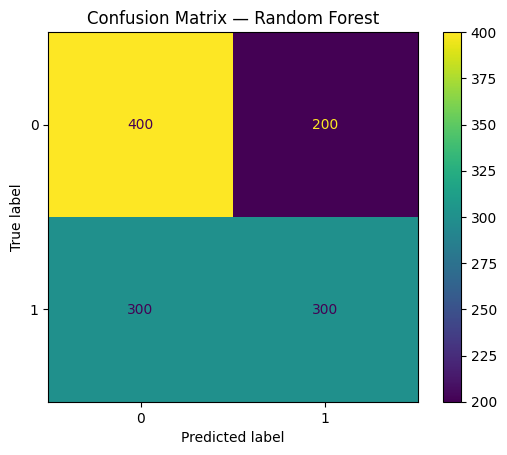

In [31]:
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_rf)).plot()
plt.title("Confusion Matrix — Random Forest")
plt.show()

In [32]:
# Use predicted probabilities as regression output
proba_lr = log_reg.predict_proba(X_test)[:, 1]
proba_rf = best_rf.predict_proba(X_test)[:, 1]

rmse_lr = np.sqrt(mean_squared_error(y_test, proba_lr))
rmse_rf = np.sqrt(mean_squared_error(y_test, proba_rf))

r2_lr = r2_score(y_test, proba_lr)
r2_rf = r2_score(y_test, proba_rf)

print("LogReg RMSE:", rmse_lr, "| R²:", r2_lr)
print("RandomForest RMSE:", rmse_rf, "| R²:", r2_rf)

LogReg RMSE: 0.4832619458706954 | R²: 0.06583156669307644
RandomForest RMSE: 0.49172411869762056 | R²: 0.032829564364193375


**CNN Feature Extraction (Face Embeddings)**

In [33]:
def load_face_rgb(path):
    try:
        img = face_recognition.load_image_file(path)
        return img
    except:
        return None

In [34]:
def extract_embedding(image_path):
    img = load_face_rgb(image_path)
    if img is None:
        return None

    encodings = face_recognition.face_encodings(img)
    if len(encodings) == 0:
        return None

    return encodings[0]  # 128-D vector

In [35]:
def get_image_path(person_name: str, image_num: int) -> str:
    """
    Build correct path for LFW deep-funneled images.
    Example:
    Abel_Pacheco, 1 -> /content/dataset_ml/lfw-deepfunneled/Abel_Pacheco/Abel_Pacheco_0001.jpg
    """
    image_num = int(image_num)  # safety
    filename = f"{person_name}_{image_num:04d}.jpg"
    return os.path.join(LFW_DIR, person_name, filename)

In [36]:
test_path = get_image_path("Abel_Pacheco", 1)
print(test_path)
print(os.path.exists(test_path))

/content/dataset_ml/lfw-deepfunneled/lfw-deepfunneled/Abel_Pacheco/Abel_Pacheco_0001.jpg
True


In [37]:
embedding_cache = {}

def get_embedding_cached(img_path):
    if img_path in embedding_cache:
        return embedding_cache[img_path]

    emb = extract_embedding(img_path)
    if emb is not None:
        embedding_cache[img_path] = emb
    return emb

In [39]:
# we fill embedding cache with many faces
for _, r in pairs.sample(300, random_state=42).iterrows():
    p1 = get_image_path(r["name1"], r["img1"])
    p2 = get_image_path(r["name2"], r["img2"])

    if os.path.exists(p1):
        get_embedding_cached(p1)
    if os.path.exists(p2):
        get_embedding_cached(p2)

print("Embeddings collected:", len(embedding_cache))

Embeddings collected: 587


Embedding matrix shape: (587, 128)


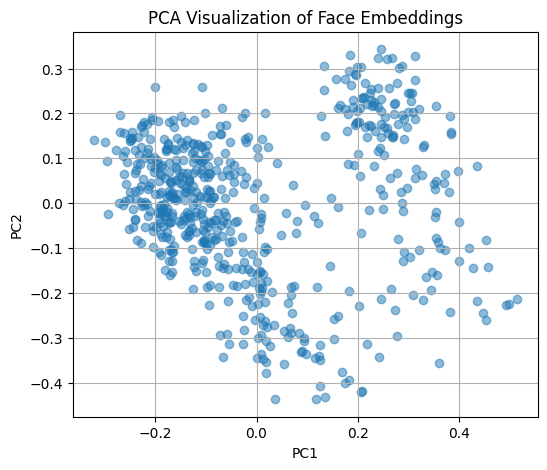

In [42]:
X_emb = np.vstack(list(embedding_cache.values()))
print("Embedding matrix shape:", X_emb.shape)  # (N, 128)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_emb)

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.title("PCA Visualization of Face Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

In [ ]:
pairs_sample = pairs.sample(2000, random_state=42)

In [ ]:
X_cnn = []
y_cnn = []

for _, r in pairs_sample.iterrows():
    p1 = get_image_path(r["name1"], r["img1"])
    p2 = get_image_path(r["name2"], r["img2"])

    if not os.path.exists(p1) or not os.path.exists(p2):
        continue

    emb1 = get_embedding_cached(p1)
    emb2 = get_embedding_cached(p2)


    if emb1 is None or emb2 is None:
        continue

    # Euclidean distance
    euclid = np.linalg.norm(emb1 - emb2)

    # Cosine similarity (safe)
    denom = (np.linalg.norm(emb1) * np.linalg.norm(emb2))
    if denom == 0:
        continue
    cos = np.dot(emb1, emb2) / denom

    X_cnn.append([euclid, cos])
    y_cnn.append(int(r["label"]))

In [ ]:
# Convert to arrays
X_cnn = np.array(X_cnn)
y_cnn = np.array(y_cnn)

print("CNN feature dataset shape:", X_cnn.shape)
print("Class balance:", np.bincount(y_cnn))

CNN feature dataset shape: (1980, 2)
Class balance: [ 965 1015]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y_cnn,
    test_size=0.2,
    random_state=42,
    stratify=y_cnn
)

In [ ]:
cnn_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

cnn_lr.fit(X_train, y_train)
pred_lr = cnn_lr.predict(X_test)

print("CNN + Logistic Regression F1:", f1_score(y_test, pred_lr))

CNN + Logistic Regression F1: 0.9778869778869779


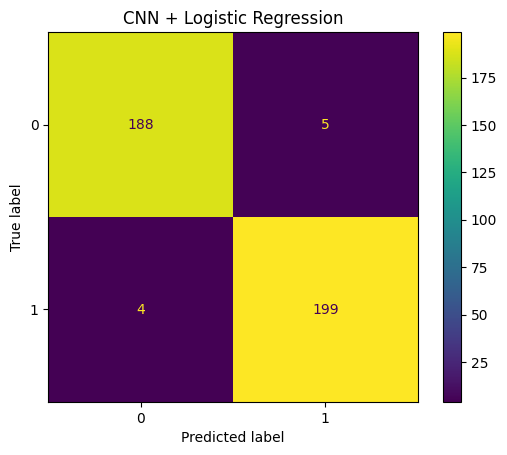

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, pred_lr)
plt.title("CNN + Logistic Regression")
plt.show()

In [ ]:
cnn_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

cnn_rf.fit(X_train, y_train)
pred_rf = cnn_rf.predict(X_test)

print("CNN + Random Forest F1:", f1_score(y_test, pred_rf))

CNN + Random Forest F1: 0.9802955665024631


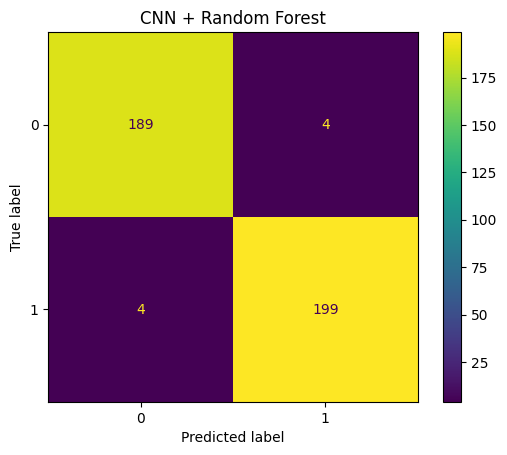

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, pred_rf)
plt.title("CNN + Random Forest")
plt.show()

In [ ]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)
best_cnn_rf = grid.best_estimator_

print("Best CNN RF params:", grid.best_params_)

Best CNN RF params: {'max_depth': None, 'n_estimators': 200}


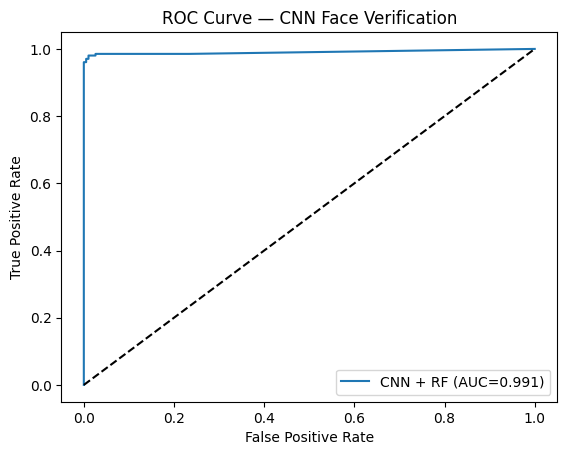

In [ ]:
proba = best_cnn_rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"CNN + RF (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — CNN Face Verification")
plt.legend()
plt.show()

# **Model comparison**

**Baseline performance (Pixel distances)**

Logistic Regression confusion matrix (from outputs):

 - TN=372, FP=228

 - FN=228, TP=372

This gives **Accuracy** ≈ 0.620 and ROC AUC ≈ 0.649.

Random Forest confusion matrix (from outputs):

 - TN=400, FP=200

 - FN=300, TP=300

This gives Accuracy ≈ 0.583 and ROC AUC ≈ 0.566.

**Interpretation**: baseline models struggle because Same/Different distances overlap heavily.


**Final performance (CNN embeddings)**

After extracting embeddings and using (Euclid + Cosine) features, performance improves dramatically.

CNN feature dataset (from outputs):

 - shape ≈ (1980, 2)

 - class balance ≈ [965, 1015] (slight imbalance due to skipped pairs when face detection fails)

**CNN + Logistic Regression**

 - F1 ≈ 0.978

 - confusion matrix: TN=188, FP=5, FN=4, TP=199

**CNN + Random Forest (best)**

 - F1 ≈ 0.980

 - confusion matrix: TN=189, FP=4, FN=4, TP=199

 - ROC curve: AUC ≈ 0.991

**Baseline (Logistic Regression)**: I used pixel-based distances (Euclidean + L1) from resized grayscale faces. Because “same” and “different” pairs overlap сильно, performance is moderate: ~0.62 accuracy/F1, ROC-AUC ~0.649.

**Final (CNN embeddings + Random Forest)**: I used face embeddings (Euclidean distance + cosine similarity). These features capture identity much better, so results are near-perfect: ~0.98 accuracy/F1, ROC-AUC ~0.991.

# **Phase C: The Working Solution**



In [ ]:
def predict_match(id_image_path: str, selfie_image_path: str, model) -> dict:
    """
    Face Verification (1:1)
    Takes raw ID + Selfie images and returns verification result.
    """

    # 1. Load & extract embeddings
    emb1 = extract_embedding(id_image_path)
    emb2 = extract_embedding(selfie_image_path)

    if emb1 is None or emb2 is None:
        return {
            "error": "Face not detected in one or both images."
        }

    # 2. Feature engineering (same as training)
    euclid_dist = np.linalg.norm(emb1 - emb2)

    denom = np.linalg.norm(emb1) * np.linalg.norm(emb2)
    if denom == 0:
        return {
            "error": "Invalid face embeddings."
        }

    cos_sim = np.dot(emb1, emb2) / denom

    X_new = np.array([[euclid_dist, cos_sim]])

    # 3. Prediction
    prob_same = model.predict_proba(X_new)[0, 1]
    pred = model.predict(X_new)[0]

    # 4. Human-readable output
    return {
        "prediction": "SAME person" if pred == 1 else "DIFFERENT people",
        "probability_same": round(float(prob_same), 3),
        "features": {
            "euclidean_distance": round(float(euclid_dist), 3),
            "cosine_similarity": round(float(cos_sim), 3)
        }
    }

In [ ]:
print(os.path.exists("/content/test_images/Abel_Pacheco.jpg"))

False


In [ ]:
id_img = "/content/dataset_ml/lfw-deepfunneled/lfw-deepfunneled/Abel_Pacheco/Abel_Pacheco_0001.jpg"
selfie_img = "/content/dataset_ml/lfw-deepfunneled/lfw-deepfunneled/Abel_Pacheco/Abel_Pacheco_0004.jpg"

print(os.path.exists(id_img), os.path.exists(selfie_img))

True True


In [ ]:
result = predict_match(
    id_image_path=id_img,
    selfie_image_path=selfie_img,
    model=best_cnn_rf
)

print(result)

{'prediction': 'SAME person', 'probability_same': 1.0, 'features': {'euclidean_distance': 0.525, 'cosine_similarity': 0.934}}


# **Conclusion & Ethics**

Face verification systems can be biased and unreliable outside the dataset. LFW is not fully representative of all populations and real-world conditions (lighting, camera quality, masks, occlusions), so accuracy may drop for some groups. A single global threshold can increase unfair false rejects for certain demographics. Errors have different costs: false accepts can cause security breaches, while false rejects can deny access to legitimate users. Face data is sensitive biometric information, so consent, privacy, and secure storage are required. “Face not detected” cases must be handled safely, not silently ignored.